In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Adapt levels:", sorted(df["Adapt"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 624 rows from spikes\all_networks_metrics.csv
Columns: ['Session', 'Channel', 'Network', 'Adapt', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Adapt levels: [0, 2, 20, 120]


,Session,Channel,Network,Adapt,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-24_11-34-51,30,adapt20_3b,120,25,16,46,0.609756,0.352113,0.446429,34.709333,152,71
1,2025-09-23_15-50-26,28,adapt20_3b,120,133,114,6,0.538462,0.956835,0.689119,22.560652,2307,139
2,2025-09-25_11-21-53,21,adapt20_3b,120,167,82,35,0.670683,0.826733,0.740576,24.250699,1689,202
3,2025-09-24_15-13-10,14,adapt20_3b,120,84,52,0,0.617647,1.000000,0.763636,16.757540,1789,84
4,2025-09-25_16-41-14,21,adapt20_3b,120,127,185,17,0.407051,0.881944,0.557018,24.292126,2903,144


In [4]:
df.loc[(df["Network"] =="updnb4ds_100_7") &  (df["Session"] == "2025-09-25_16-41-14") & (df["Adapt"]==0)]

,Session,Channel,Network,Adapt,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
612,2025-09-25_16-41-14,21,updnb4ds_100_7,0,106,83,38,0.560847,0.736111,0.636637,29.144025,2125,144


In [5]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

df=df[~df["Session"].isin(sessions_to_reject)]
print(df["Session"].unique())
# df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-24_11-34-51' '2025-09-23_15-50-26' '2025-09-25_11-21-53'
 '2025-09-25_16-41-14' '2025-09-24_10-24-40' '2025-09-22_17-42-27'
 '2025-09-23_16-17-52' '2025-09-22_17-55-26' '2025-09-24_16-29-07']


In [6]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby("Network")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


,F1,Precision,Recall,TP,FP,FN
Network,,,,,,
dsb4updn_median_200_11b,0.548,0.505,0.690,84.917,85.167,32.194
dsb4updn_median_200_16b,0.543,0.489,0.720,88.250,99.833,28.861
updnb4ds_100_13f,0.541,0.599,0.584,71.583,49.917,45.528
adapt20_3b,0.540,0.466,0.762,92.750,118.278,24.361
dsb4updn_median_200_11f,0.540,0.528,0.637,78.278,69.083,38.833
dsb4updn_median_200_13f,0.540,0.518,0.651,80.000,75.806,37.111
updnb4ds_100_13b,0.540,0.590,0.589,72.194,51.750,44.917
dsb4updn_median_200_15f,0.536,0.473,0.706,86.333,98.833,30.778
updnb4ds_100_7,0.529,0.537,0.602,74.222,61.417,42.889


In [7]:
print(summary.loc[summary["F1"].idxmax()])

F1            0.548
Precision     0.505
Recall        0.690
TP           84.917
FP           85.167
FN           32.194
Name: dsb4updn_median_200_11b, dtype: float64


In [9]:
# Print summary
print("\n--- Summary by Adapt ---")
summary = df.groupby("Adapt")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3)
summary = summary.reindex([0, 120, 20, 2])
display(summary)


--- Summary by Adapt ---


,F1,Precision,Recall,TP,FP,FN
Adapt,,,,,,
0,0.578,0.541,0.697,64.0,66.5,36.0
120,0.568,0.547,0.702,59.0,62.0,33.5
20,0.573,0.564,0.707,62.0,59.0,36.5
2,0.550,0.594,0.609,53.0,39.5,42.5


In [10]:
# Print summary
print("\n--- Summary by Session ---")
summary = df.groupby("Session")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Session ---


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-22_17-55-26,0.732,0.656,0.854,157.958,90.458,27.042
2025-09-23_15-50-26,0.693,0.631,0.796,110.708,69.667,28.292
2025-09-25_11-21-53,0.677,0.747,0.643,129.792,47.479,72.208
2025-09-25_16-41-14,0.613,0.526,0.766,110.333,107.417,33.667
2025-09-24_10-24-40,0.562,0.565,0.594,54.625,46.479,37.375
2025-09-23_16-17-52,0.481,0.513,0.505,36.333,39.458,35.667
2025-09-22_17-42-27,0.443,0.540,0.402,43.854,42.896,65.146
2025-09-24_16-29-07,0.283,0.171,0.897,35.896,191.792,4.104
2025-09-24_11-34-51,0.274,0.517,0.199,14.146,14.896,56.854


In [9]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

C:\Users\NCN\AppData\Local\Temp\ipykernel_11280\1820129339.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)


N=108 matched samples for statistics.
0 vs 2: p=0.0348
120 vs 2: p=0.0160


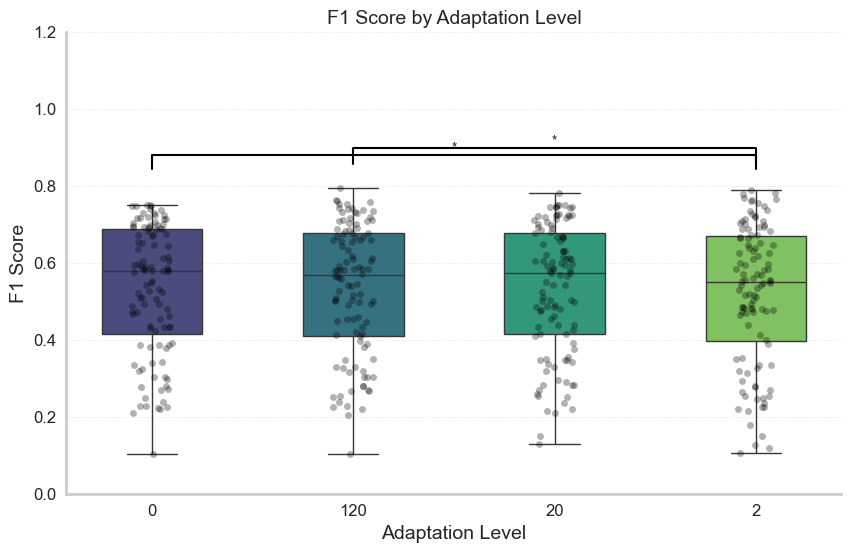

In [10]:
def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Adapt"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.stripplot(x="Adapt", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel", "Network"]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Score by Adaptation Level{title_suffix}",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()

if 'df' in locals():
    plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_network=False)

0 vs 120: p=0.5653
0 vs 20: p=0.8167
0 vs 2: p=0.0348
120 vs 20: p=0.7084
120 vs 2: p=0.0160
20 vs 2: p=0.0594


C:\Users\NCN\AppData\Local\Temp\ipykernel_11280\2455164002.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
C:\Users\NCN\AppData\Local\Temp\ipykernel_11280\2455164002.py:80: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Fixed","60", "10", "1"])


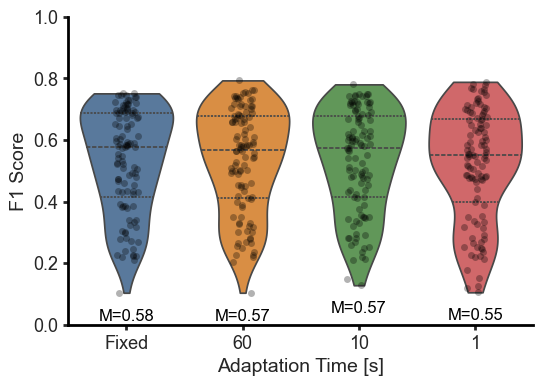

In [11]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Adapt"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(6, 4))
    
    colors=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

    # Violin plot
    sns.violinplot(x="Adapt", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Adapt", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel", "Network"]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Adapt", values=metric)
    # display(pivot.head())
    pivot = pivot.dropna()

    # Annotate medians and N
    medians = plot_df.groupby('Adapt')[metric].median()
    counts = plot_df.groupby('Adapt')[metric].count()
    mins=plot_df.groupby('Adapt')[metric].min() 
        
    for i, adapt in enumerate(desired_order):
        if adapt in medians:
            val = medians[adapt]
            min_val = mins[adapt]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    # ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0,1) 

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.3)
    ax.spines[['bottom','left']].set_color('black')
    ax.set_xticklabels(["Fixed","60", "10", "1"])
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2)
    ax.tick_params(axis='x', rotation=0)

    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Adaptation Time [s]",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()
    return fig,ax

if 'df' in locals():
    fig,ax=plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    os.makedirs("figures", exist_ok=True)
    # fig.savefig("figures/f1_violin_by_adapt.svg", dpi=300, bbox_inches='tight')
    # fig.savefig("figures/f1_violin_by_adapt.png",dpi=300)

C:\Users\NCN\AppData\Local\Temp\ipykernel_11280\2378848502.py:27: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


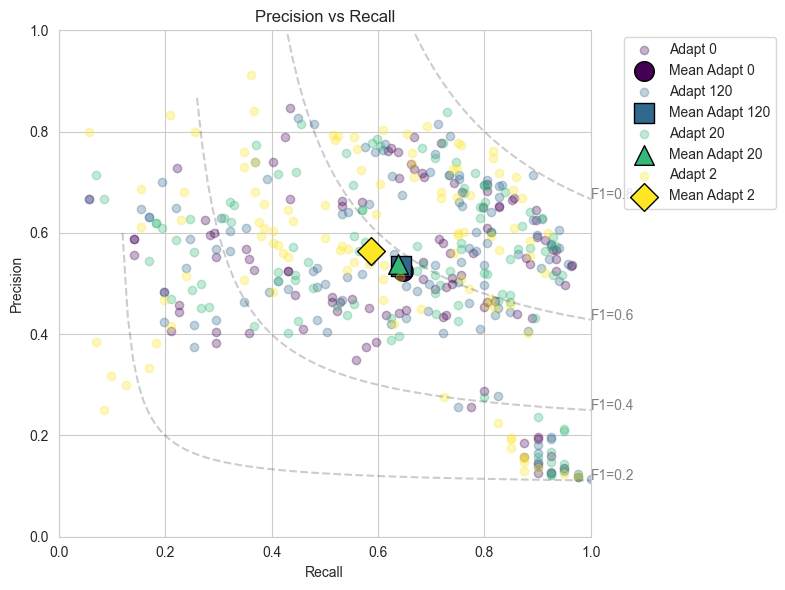

In [12]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Adapt"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Adapt {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Adapt {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if 'df' in locals():
    plot_precision_recall(df)

C:\Users\NCN\AppData\Local\Temp\ipykernel_11280\284244858.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Adapt", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)


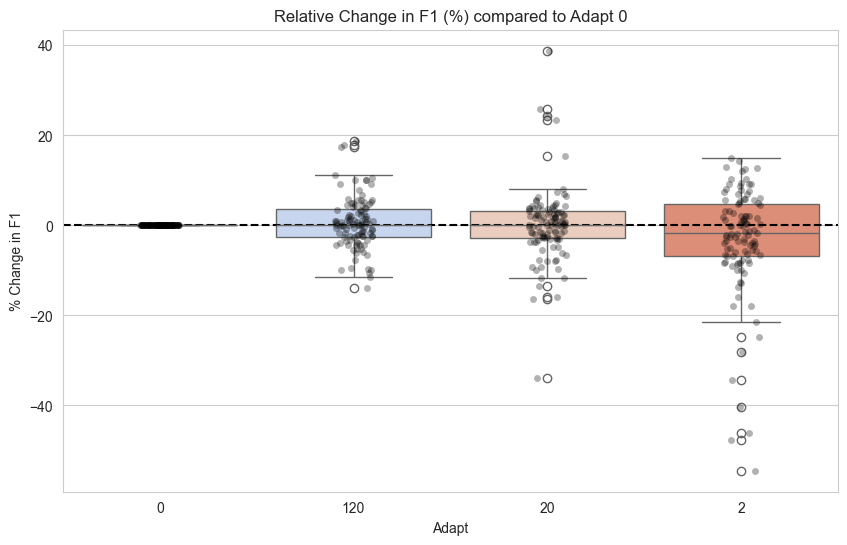

In [13]:
def plot_relative_change(df, metric="F1"):
    # Pivot to have Adapt as columns
    pivot_cols = ["Session", "Channel", "Network"]
    if "Dataset" in df.columns:
        pivot_cols.append("Dataset")
        
    pivot = df.pivot_table(index=pivot_cols, columns="Adapt", values=metric) # Pivot table
    # print(pivot.head())
    # Calculate change relative to Adapt 0 (or lowest adapt value)
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    baseline_adapt = 0
    
    if baseline_adapt not in pivot.columns:
        print(f"Baseline adapt {baseline_adapt} not found in pivot columns.")
        return

    changes = pd.DataFrame()
    for col in pivot.columns:
        changes[col] = (pivot[col] - pivot[baseline_adapt]) / pivot[baseline_adapt] * 100
        
    # Melt for plotting
    melted = changes.melt(var_name="Adapt", value_name="Percent Change")
    # print(melted)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Adapt", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)
    # Overlay points
    sns.stripplot(x="Adapt", y="Percent Change", data=melted, color="black", alpha=0.3, jitter=True, order=adapt_values)

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Relative Change in {metric} (%) compared to Adapt {baseline_adapt}")
    plt.ylabel(f"% Change in {metric}")
    plt.show()

if 'df' in locals():
    plot_relative_change(df, "F1")

,Session,Channel,Network,Adapt,Metric,Value
0,2025-09-22_17-55-26,26,adapt20_3b,20,Precision,0.516224
1,2025-09-25_16-41-14,21,adapt20_3b,20,Precision,0.431438
2,2025-09-23_16-17-52,24,adapt20_3b,20,Precision,0.425197
3,2025-09-22_17-42-27,24,adapt20_3b,20,Precision,0.456000
4,2025-09-24_11-34-51,30,adapt20_3b,20,Precision,0.621622


C:\Users\NCN\AppData\Local\Temp\ipykernel_11280\256095606.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette=custom_palette, inner='quartile', cut=0, order=order, alpha=1.0, linewidth=2)


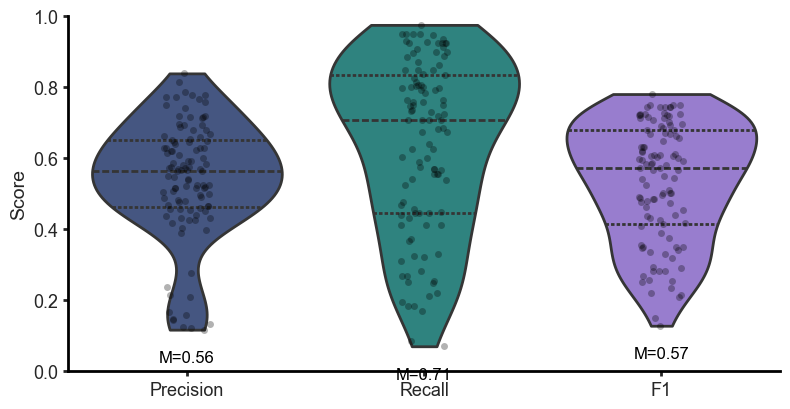

In [19]:
# Plot Precision, Recall and F1 for a single Adaptation level in the same figure
def plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False, metrics=("Precision", "Recall", "F1")):
    """Plot the distributions of multiple metrics for a single `adapt` value in one plot."""
    # Ensure adapt exists in the dataframe
    if adapt not in df["Adapt"].unique():
        print(f"Adapt {adapt} not present in dataframe. Available: {sorted(df['Adapt'].unique())}")
        return

    # Prepare data for the requested adapt
    if aggregate_by_network:
        agg_cols = ['Network', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].mean().reset_index()
        title_suffix = ' (Averaged by Network)'
    else:
        plot_df = df.copy()
        title_suffix = ''

    plot_df = plot_df[plot_df['Adapt'] == adapt]
    if len(plot_df) == 0:
        print(f'No rows for Adapt {adapt} after filtering.')
        return

    # Melt metrics into long form for plotting
    id_vars = [c for c in ['Session', 'Channel', 'Network', 'Adapt'] if c in plot_df.columns]
    melted = plot_df.melt(id_vars=id_vars, value_vars=list(metrics), var_name='Metric', value_name='Value')
    display(melted.head())
    # Plot
    fig, ax = plt.subplots(figsize=(8, 4.2))
    order = list(metrics)
    snn_color = "#9370DB" 
    # Create custom palette: 2 colors from viridis, then the SNN color
    viridis_colors = sns.color_palette("viridis", n_colors=3)
    custom_palette = [viridis_colors[0], viridis_colors[1], snn_color]

    sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette=custom_palette, inner='quartile', cut=0, order=order, alpha=1.0, linewidth=2)
    sns.stripplot(x='Metric', y='Value', data=melted, ax=ax, color='k', alpha=0.3, jitter=True, order=order)

    # Annotate medians and N
    medians = melted.groupby('Metric')['Value'].median()
    counts = melted.groupby('Metric')['Value'].count()
    mins=melted.groupby('Metric')['Value'].min() 
    
    for i, metric in enumerate(order):
        if metric in medians:
            val = medians[metric]
            min_val = mins[metric]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    ax.set_ylim(0, 1)
    # ax.set_title(f'Performance Metrics', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_xlabel('')
    # ax.set_xlabel('Metric', fontsize=14)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    # ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    plt.tight_layout()
    plt.show()
    return fig, ax

if 'df' in locals():
    fig,ax=plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False)
    # plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    fig.savefig("figures/metrics_single_adapt.svg", format="svg")
    fig.savefig("figures/metrics_single_adapt.png", format="png", dpi=300)